In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd /Users/armandoroqueestrada/Proyecto_Proca/stability

/Users/armandoroqueestrada/Proyecto_Proca/Stability


In [3]:
import Modules.Background as bg
import numpy as np

import matplotlib.pyplot as plt
import Modules.Plot as cplot

In [4]:
cplot.general()

### Cargando perfiles

In [5]:
Family_rad_polarization_LPn0 = np.load("/Users/armandoroqueestrada/Proyecto_Proca/Stability/background_data_profiles_lambda_n_case/Family_radial_polarization_LPn0.npy", allow_pickle=True)
Family_rad_polarization_LNn0 = np.load("/Users/armandoroqueestrada/Proyecto_Proca/Stability/background_data_profiles_lambda_n_case/Family_radial_polarization_LNn0.npy", allow_pickle=True)

In [6]:
len(Family_rad_polarization_LPn0), len(Family_rad_polarization_LNn0)

(56, 55)

(0.0, 15.0)

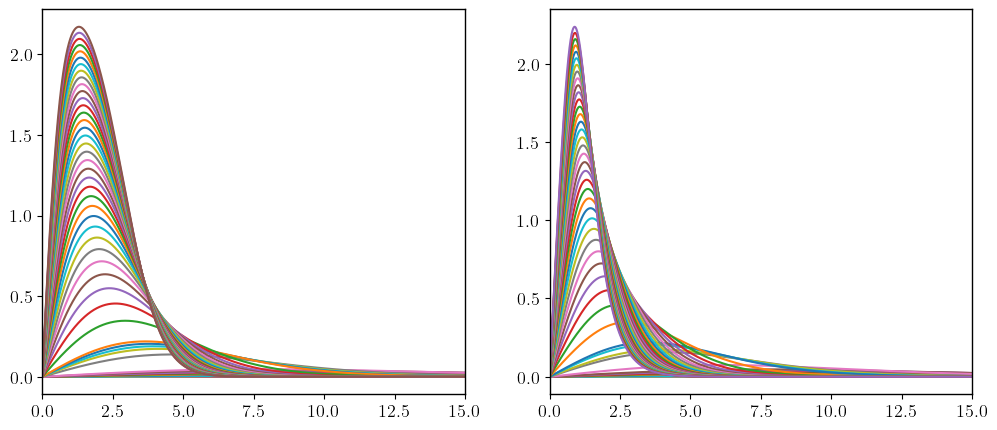

In [7]:
# [Ei, rDnew, sDnew, dsDnew, uDnew, duDnew]

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

for dat in Family_rad_polarization_LPn0:
    ax[0].plot(dat[1], dat[1] * dat[2], label=fr"$\sigma_{0}={dat[2][0]:.3f}$")

for dat in Family_rad_polarization_LNn0:
    ax[1].plot(dat[1], dat[1] * dat[2], label=fr"$\sigma_{0}={dat[2][0]:.3f}$")

ax[0].set_xlim(0, 15)
ax[1].set_xlim(0, 15)

### Stability 

In [6]:
import Modules.SpectralMeth as sp
from scipy.interpolate import interp1d

In [7]:
# n = 0
s0 = Family_rad_polarization_LPn0
s0M = Family_rad_polarization_LNn0

In [26]:
# Perfiles Jose:

In [9]:
from scipy.integrate import quad, simpson
from scipy.interpolate import interp1d

def massVal(r, sigtot, gamma=0, fac=4*np.pi, 
            kind='quadratic', fill_value="extrapolate",
            integrationMetho='quad'):
    """
    """

    # Ensure r and sigtot are sorted
    if not all(r[i] < r[i+1] for i in range(len(r)-1)):
        raise ValueError("Input array `r` must be strictly increasing.")
    
    # Ensure that gamma is either 0 or 1
    if gamma not in [0, 1]:
        raise ValueError("gamma value must be 0 or 1.")
    
    if integrationMetho == 'quad':
        # Interpolate sigtot
        sigF = interp1d(r, sigtot, kind=kind, fill_value=fill_value)

        # Define the integrand Bf(r)
        Bf = lambda r: r**(2 * (gamma + 1)) * sigF(r)
        # Integration limits
        rmin, rmax = r[0], r[-1]
        # Perform the numerical integration
        integral_result, error = quad(Bf, rmin, rmax)

        if error > 1e-5:  # Large error margin, can be adjusted
            print(f"Warning: The integral may not have converged well. Error estimate: {error}")
    elif integrationMetho == 'simpson':
        integral_result = simpson(r**(2 * (gamma + 1))*sigtot, r)
    else:
        integral_result = np.trapz(r**(2 * (gamma + 1))*sigtot, r)
        
    # Calculate the mass (Mas)
    Mas = fac * integral_result  # masa: c*hb/(G*m*Lambda^(1/2))  -> Lambda=4pi m^3/Mp^2
    return Mas

In [10]:
data_save = []
choos = [3, -12, -4, -2]
LamV = 1
gamma = 1
for ind in choos:
    s = s0[ind] 
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s
    Mass = massVal(rDnew, sDnew**2, gamma=gamma, integrationMetho='simpson')

    print('==> ', sDnew[0], Mass, Ei)

    data_save.append([Ei, Mass, rDnew,
                 rDnew**gamma * sDnew,
                 rDnew**(gamma-1) * (gamma * sDnew[0] + rDnew*dsDnew),
                 uDnew, duDnew, LamV])

np.savez("radial_self_repulsivo.npz", np.array(data_save, dtype=object))

==>  0.0003 7.99362350872509 -0.010916975774609913
==>  2.4 308.12686563001154 -6.173356938952464
==>  3.2 378.61794996470877 -7.9136066278108235
==>  3.4 396.08329198576536 -8.344273675576407


In [11]:
data_save = []
choos = [15, 20, 25, -5]
LamV = -1
gamma = 1
for ind in choos:
    s = s0M[ind] 
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s
    Mass = massVal(rDnew, sDnew**2, gamma=gamma, integrationMetho='simpson')

    print('==> ', sDnew[0], Mass, Ei)

    data_save.append([Ei, Mass, rDnew,
                 rDnew**gamma * sDnew,
                 rDnew**(gamma-1) * (gamma * sDnew + rDnew*dsDnew),
                 uDnew, duDnew, LamV])

np.savez("radial_self_atractivo.npz", np.array(data_save, dtype=object))

==>  0.01 25.187295291197238 -0.1118069092388488
==>  0.1 51.59593428194173 -0.4999155294350095
==>  0.6 74.71795480897671 -1.4822292041147185
==>  3.1 75.77300713777421 -3.441093478122756


In [8]:
s0[54][2][0]

3.4

##################################################
==>  3.4
rMax = 400, Nptos = 400


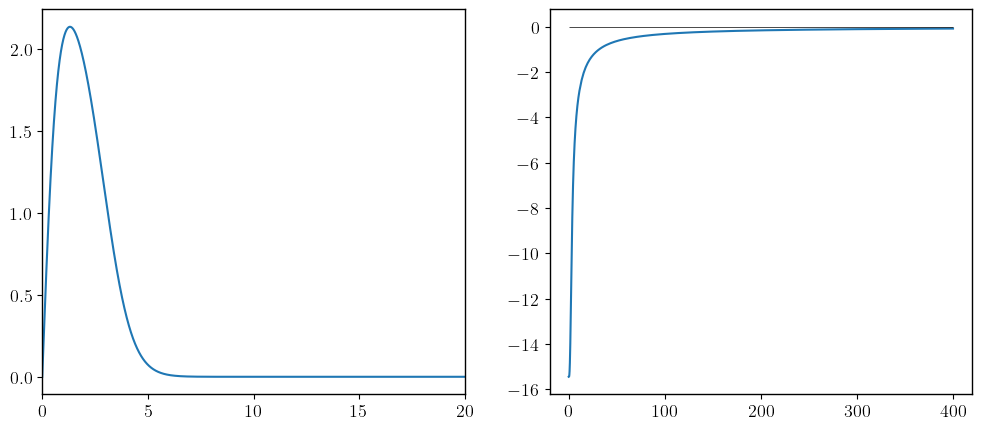

Jval = 0: [####################] 100%
[]
Jval = 1
[-0.10393765+0.73412319j  0.10393765+0.73412319j  0.10393765-0.73412319j
 -0.10393765-0.73412319j]
Jval = 2
[-1.31524142e-06+2.52744975e-11j  1.31524142e-06-2.53010828e-11j]
Jval = 3
[]


In [9]:
lambdaValGeneral, dataExtraGeneral = [[], []], [[], []]
datFuncGeneral = [[], []]

polariz = 'radial'

Jval = [0, 1, 2, 3]
alp = 0.0
ln = [1.] # -1., 
for cont0, conf in enumerate([s0]):  #s0M s0
    print('#' * 50)
    lamV = [ln[cont0], 0] # ln, ls
    for cont, s in enumerate(conf[54:55], start=54): 
        Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s
        print('==> ', sDnew[0])
        datFunc = [
            [interp1d(rDnew, rDnew * sDnew)],
            [interp1d(rDnew, uDnew)],
        ]

        #if cont < 2:
        #    rMax = 7000
        #    Nptos = 850
        #elif cont < 10:
        #    rMax = 1200
        #    Nptos = 700
        #else:
        rMax = 400 #800
        Nptos = 400 #600
        print(f"rMax = {rMax}, Nptos = {Nptos}")

        # Graphing
        rad2 = np.linspace(0, rMax, 500000)
        fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

        ax[0].plot(rad2, np.abs(datFunc[0][0](rad2)))
        ax[1].plot(rad2, Ei - datFunc[1][0](rad2))
        ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
        ax[0].set_xlim(0, 20)
        #ax[0].set_yscale('log')    
        plt.show()

        lambdaVal, dataExtra = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)
    
        for ind, [Jval_temp, data] in enumerate(dataExtra):
            rdis, eingVal, eigVect = data
            print('Jval = %d'%Jval_temp)
            ind = np.abs(np.real(eingVal)) >= 1e-08 # filtrando los autovalores reales
            print(eingVal[ind])

        # Save data
        datFuncGeneral[cont0].append(datFunc)
        lambdaValGeneral[cont0].append(lambdaVal)
        dataExtraGeneral[cont0].append(dataExtra)

In [10]:
data_real_save = []
for cont, dataExtra in enumerate(dataExtraGeneral[0]):
    temp = datFuncGeneral[0][cont]
    s0Dat = temp[0][0](0)
    dataJ = []
    for ind, [Jval_temp, data] in enumerate(dataExtra):
        rdis, eingVal, eigVect = data
        ind = np.abs(np.real(eingVal)) >= 1e-06 # filtrando los autovalores reales
        dataJ.append([Jval_temp, float(s0Dat), rdis if sum(ind)!=0 else [], eingVal[ind], eigVect[:, ind]])
    data_real_save.append(dataJ)

In [11]:
def pert(lam, A, B, t=1):
    sigma = (A + B) * np.exp(lam * t) + np.conjugate((A - B))*np.exp(np.conjugate(lam) * t)
    return sigma

Jval = 0
[]
Jval = 1
[-0.10393765+0.73412319j  0.10393765+0.73412319j  0.10393765-0.73412319j
 -0.10393765-0.73412319j]
Jval = 2
[-1.31524142e-06+2.52744975e-11j  1.31524142e-06-2.53010828e-11j]
Jval = 3
[]


/var/folders/mf/vfyq6zyn4l35gfd2kgq4k2q00000gn/T/ipykernel_34596/3474833698.py:40: ComplexWarning: Casting complex values to real discards the imaginary part
  ax[0][0].text(x=20, y=-0.05, s=r'%5.5f'%eingVal[ind][0])
/var/folders/mf/vfyq6zyn4l35gfd2kgq4k2q00000gn/T/ipykernel_34596/3474833698.py:41: ComplexWarning: Casting complex values to real discards the imaginary part
  ax[1][0].text(x=20, y=-0.05, s=r'%5.5f'%eingVal[ind][1])


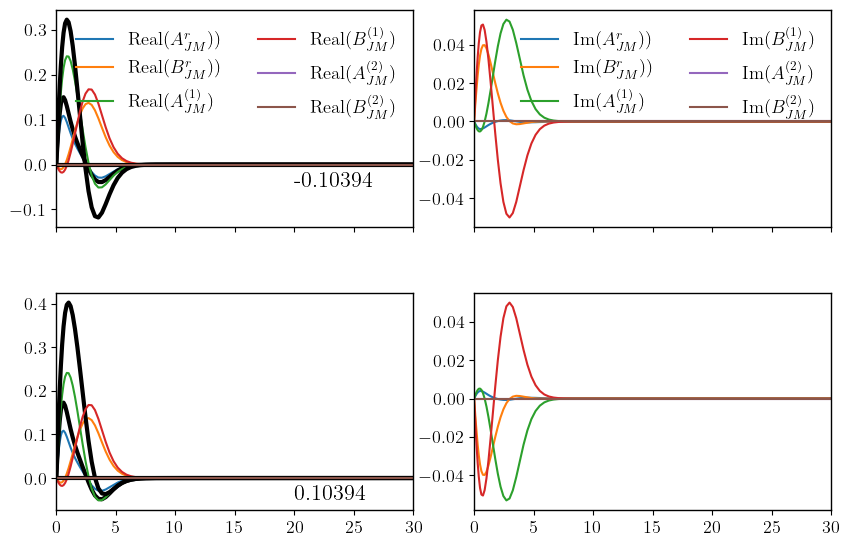

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 6.5),
                       sharex=True, sharey=False,
                       gridspec_kw=dict(hspace=0.3, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )

# dataExtra.append([J, list([r_dis2, LambdaRealSorted, eig_vectors_sorted[:, jj]])])
for ind, [Jval, data] in enumerate(dataExtra):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)    
    ind = np.abs(np.real(eingVal)) >= 1e-07 # filtrando los autovalores reales
    print(eingVal[ind])
    
    if Jval==2:
        labels = ['$A_{JM}^{r}$)', '$B_{JM}^{r})$', '$A_{JM}^{(1)}$', '$B_{JM}^{(1)}$', '$A_{JM}^{(2)}$', '$B_{JM}^{(2)}$']
        datay = (eigVect[:, ind])[:, 0]
        for i in range(6):
            ax[0][0].plot(rdis, np.real(datay[i*(Nptos-1): (i+1)*(Nptos-1)]), label=r'Real(%s)'%labels[i])
            ax[0][1].plot(rdis, np.imag(datay[i*(Nptos-1): (i+1)*(Nptos-1)]), label=r'Im(%s)'%labels[i])

            if i%2 == 0:
                Ac = datay[i*(Nptos-1): (i+1)*(Nptos-1)]
                Bc = datay[(i+1)*(Nptos-1): (i+2)*(Nptos-1)]
                ax[0][0].plot(rdis, pert(eingVal[ind][0], Ac, Bc, t=1), 'k-', lw=3)
        
        ax[0][0].legend(frameon=False, fontsize='small', ncol=2)
        ax[0][1].legend(frameon=False, fontsize='small', ncol=2)
        
        datay = (eigVect[:, ind])[:, 1]
        for i in range(6):
            ax[1][0].plot(rdis, np.real(datay[i*(Nptos-1): (i+1)*(Nptos-1)]), label=r'Real(%s)'%labels[i])
            ax[1][1].plot(rdis, np.imag(datay[i*(Nptos-1): (i+1)*(Nptos-1)]), label=r'Im(%s)'%labels[i])

            if i%2 == 0:
                Ac = datay[i*(Nptos-1): (i+1)*(Nptos-1)]
                Bc = datay[(i+1)*(Nptos-1): (i+2)*(Nptos-1)]
                ax[1][0].plot(rdis, pert(eingVal[ind][1], Ac, Bc, t=1), 'k-', lw=3)
        
        #ax[0][0].plot(rad2, np.abs(datFunc[0][0](rad2)), ls='--')
        
        ax[0][0].text(x=20, y=-0.05, s=r'%5.5f'%eingVal[ind][0])
        ax[1][0].text(x=20, y=-0.05, s=r'%5.5f'%eingVal[ind][1])
        ax[0][0].set_xlim(0, 30)
        ax[0][1].set_xlim(0, 30)

In [42]:
# data_real_save

In [11]:
np.save("Real_Eingevalues_rad_polarization_LPn0", np.array(data_real_save, dtype=object))

In [ ]:
[15, 20, 25, -5]

##################################################
==>  1.9


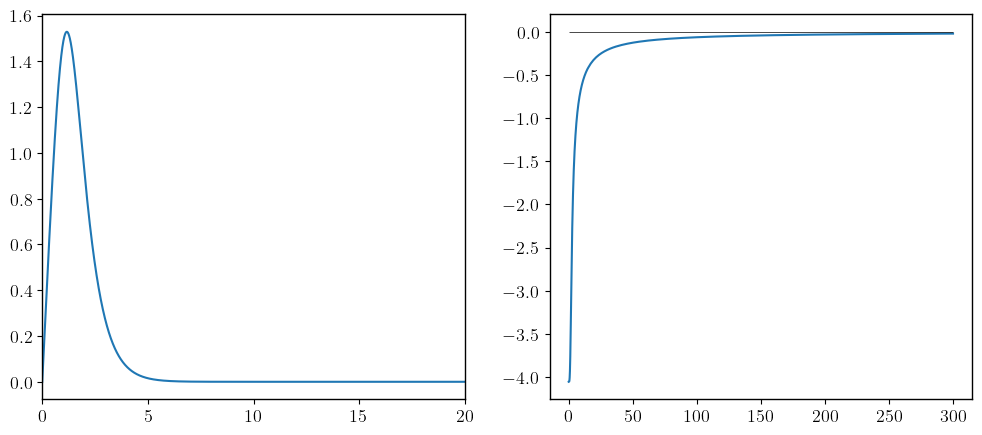

Jval = 0: [####################] 100%
[ 0.47095757-4.37982983e-14j -0.47095757-1.04187691e-13j]
Jval = 1
[-0.45635097+1.86774211j  0.45635097+1.86774211j  0.45635097-1.86774211j
 -0.45635097-1.86774211j]
Jval = 2
[-5.84209548e-06+1.07570635e-10j  5.84209548e-06-1.07497231e-10j]
Jval = 3
[]


In [28]:
lambdaValGeneral, dataExtraGeneral = [[], []], [[], []]
datFuncGeneral = [[], []]

polariz = 'radial'

Jval = [0, 1, 2, 3]
alp = 0.0
ln = [-1.] # 1., 
for cont0, conf in enumerate([s0M]):  #s0M s0
    print('#' * 50)
    lamV = [ln[cont0], 0] # ln, ls
    for cont, s in enumerate([conf[38]]): 
        Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s
        print('==> ', sDnew[0])
        datFunc = [
            [interp1d(rDnew, rDnew * sDnew)],
            [interp1d(rDnew, uDnew)],
        ]

        #if cont < 2:
        #    rMax = 7000
        #    Nptos = 800
        #elif cont < 10:
        #    rMax = 1200
        #    Nptos = 700
        #else:
        #    rMax = 800
        #    Nptos = 600
        rMax = 300 #800
        Nptos = 400
        # print(f"rMax = {rMax}, Nptos = {Nptos}")

        # Graphing
        rad2 = np.linspace(0, rMax, 500000)
        fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

        ax[0].plot(rad2, np.abs(datFunc[0][0](rad2)))
        ax[1].plot(rad2, Ei - datFunc[1][0](rad2))
        ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
        ax[0].set_xlim(0, 20)
        # ax[0].set_yscale('log')    
        plt.show()

        lambdaVal, dataExtra = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)
    
        for ind, [Jval_temp, data] in enumerate(dataExtra):
            rdis, eingVal, eigVect = data
            print('Jval = %d'%Jval_temp)
            ind = np.abs(np.real(eingVal)) >= 1e-08 # filtrando los autovalores reales
            print(eingVal[ind])

        # Save data
        datFuncGeneral[cont0].append(datFunc)
        lambdaValGeneral[cont0].append(lambdaVal)
        dataExtraGeneral[cont0].append(dataExtra)

In [25]:
def pert(lam, A, B, t=1):
    sigma = (A + B) * np.exp(lam * t) + np.conjugate((A - B))*np.exp(np.conjugate(lam) * t)
    return sigma

Jval = 0
[ 0.47095757-4.37982983e-14j -0.47095757-1.04187691e-13j]
Jval = 1
[-0.45635097+1.86774211j  0.45635097+1.86774211j  0.45635097-1.86774211j
 -0.45635097-1.86774211j]
Jval = 2
[-5.84209548e-06+1.07570635e-10j  5.84209548e-06-1.07497231e-10j]
Jval = 3
[]


/Users/armandoroqueestrada/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/armandoroqueestrada/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/var/folders/mf/vfyq6zyn4l35gfd2kgq4k2q00000gn/T/ipykernel_33315/691833166.py:43: ComplexWarning: Casting complex values to real discards the imaginary part
  ax[0][0].text(x=20, y=-0.05, s=r'%5.5f'%eingVal[ind][0])
/var/folders/mf/vfyq6zyn4l35gfd2kgq4k2q00000gn/T/ipykernel_33315/691833166.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  ax[1][0].text(x=20, y=-0.05, s=r'%5.5f'%eingVal[ind][1])


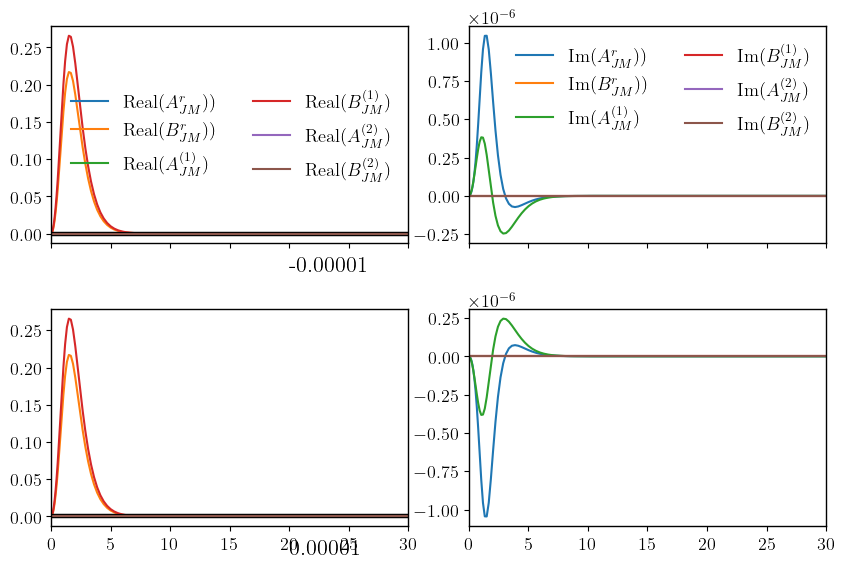

In [30]:
#rMax = 210 #200*(nodos+1) - 10
#Nptos = int(3*rMax/4) * 3

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 6.5),
                       sharex=True, sharey=False,
                       gridspec_kw=dict(hspace=0.3, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )

# dataExtra.append([J, list([r_dis2, LambdaRealSorted, eig_vectors_sorted[:, jj]])])
for ind, [Jval, data] in enumerate(dataExtra):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)    
    ind = np.abs(np.real(eingVal)) >= 1e-07 # filtrando los autovalores reales
    print(eingVal[ind])
    
    if Jval==2:
        labels = ['$A_{JM}^{r}$)', '$B_{JM}^{r})$', '$A_{JM}^{(1)}$', '$B_{JM}^{(1)}$', '$A_{JM}^{(2)}$', '$B_{JM}^{(2)}$']
        datay = (eigVect[:, ind])[:, 0]
        for i in range(6):
            ax[0][0].plot(rdis, np.real(datay[i*(Nptos-1): (i+1)*(Nptos-1)]), label=r'Real(%s)'%labels[i])
            ax[0][1].plot(rdis, np.imag(datay[i*(Nptos-1): (i+1)*(Nptos-1)]), label=r'Im(%s)'%labels[i])

            if i%2 == 0:
                Ac = datay[i*(Nptos-1): (i+1)*(Nptos-1)]
                Bc = datay[(i+1)*(Nptos-1): (i+2)*(Nptos-1)]
                ax[0][0].plot(rdis, pert(eingVal[ind][0], Ac, Bc, t=1), 'k-', lw=3)
        
        ax[0][0].legend(frameon=False, fontsize='small', ncol=2)
        ax[0][1].legend(frameon=False, fontsize='small', ncol=2)
        
        datay = (eigVect[:, ind])[:, 1]
        for i in range(6):
            ax[1][0].plot(rdis, np.real(datay[i*(Nptos-1): (i+1)*(Nptos-1)]), label=r'Real(%s)'%labels[i])
            ax[1][1].plot(rdis, np.imag(datay[i*(Nptos-1): (i+1)*(Nptos-1)]), label=r'Im(%s)'%labels[i])

            if i%2 == 0:
                Ac = datay[i*(Nptos-1): (i+1)*(Nptos-1)]
                Bc = datay[(i+1)*(Nptos-1): (i+2)*(Nptos-1)]
                ax[1][0].plot(rdis, pert(eingVal[ind][0], Ac, Bc, t=1), 'k-', lw=3)
        
        #ax[0][0].plot(rad2, np.abs(datFunc[0][0](rad2)), ls='--')
        
        ax[0][0].text(x=20, y=-0.05, s=r'%5.5f'%eingVal[ind][0])
        ax[1][0].text(x=20, y=-0.05, s=r'%5.5f'%eingVal[ind][1])
        ax[0][0].set_xlim(0, 30)
        ax[0][1].set_xlim(0, 30)

In [16]:
data_real_save = []
for cont, dataExtra in enumerate(dataExtraGeneral[0]):
    temp = datFuncGeneral[0][cont]
    s0Dat = temp[0][0](0)
    dataJ = []
    for ind, [Jval_temp, data] in enumerate(dataExtra):
        rdis, eingVal, eigVect = data
        ind = np.abs(np.real(eingVal)) >= 1e-06 # filtrando los autovalores reales
        dataJ.append([Jval_temp, float(s0Dat), rdis if sum(ind)!=0 else [], eingVal[ind], eigVect[:, ind]])
    data_real_save.append(dataJ)

In [6]:
# data_real_save

In [17]:
np.save("Real_Eingevalues_rad_polarization_LNn0", np.array(data_real_save, dtype=object))

In [ ]:
# Plot

In [93]:
Family_rad_polarization_LNn0 = np.load("/Users/armandoroqueestrada/Proyecto_Proca/Stability/background_data_profiles_lambda_n_case/Family_radial_polarization_LNn0.npy", allow_pickle=True)
Real_Eingevalues_rad_polarization_LNn0 = np.load("stability_lambda_n_case/Polarization_radial/Real_Eingevalues_rad_polarization_LNn0.npy", allow_pickle=True)


In [ ]:
for i in range(1, 22):
    [Jval_temp, s0, _, eingVal, _]
    print(Family_rad_polarization_LNn0[i][2][0])
    print(Real_Eingevalues_rad_polarization_LNn0[i][0][0], Real_Eingevalues_rad_polarization_LNn0[i][0][3])
    print(Real_Eingevalues_rad_polarization_LNn0[i][1][0], Real_Eingevalues_rad_polarization_LNn0[i][1][3])
    print(Real_Eingevalues_rad_polarization_LNn0[i][2][0], Real_Eingevalues_rad_polarization_LNn0[i][2][3])
    print(Real_Eingevalues_rad_polarization_LNn0[i][3][0], Real_Eingevalues_rad_polarization_LNn0[i][3][3])
    print()
    

5e-05
0 []
1 []
2 []
3 []

0.0001
0 []
1 []
2 []
3 []

0.0003
0 []
1 []
2 []
3 []

0.0005
0 []
1 []
2 []
3 []

0.0006
0 []
1 []
2 []
3 []

0.0007
0 []
1 []
2 []
3 []

0.0008
0 []
1 []
2 []
3 []

0.0009
0 []
1 []
2 []
3 []

0.001
0 []
1 []
2 []
3 []

0.003
0 []
1 []
2 []
3 []

0.004
0 []
1 []
2 []
3 []

0.005
0 []
1 []
2 []
3 []

0.006
0 []
1 []
2 []
3 []

0.008
0 []
1 []
2 []
3 []

0.01
0 []
1 []
2 []
3 []

0.02
0 []
1 []
2 []
3 []

0.06
0 []
1 []
2 []
3 []

0.07
0 []
1 []
2 []
3 []

0.09
0 []
1 []
2 []
3 []

0.1
0 [-8.68222947e-06-3.14108695e-11j  8.68222947e-06+3.13502543e-11j]
1 []
2 [ 1.94494087e-06-4.58536807e-12j -1.94494087e-06+5.01198182e-12j]
3 []

0.2
0 [ 1.43444712e-06+4.56497104e-11j -1.43444712e-06-4.54922101e-11j]
1 []
2 []
3 []

